In [2]:
import os
import tensorflow as tf
import tensorflow_probability as tfp # do not remove, despite not being used explicitly
import smart_control.reinforcement_learning.utils.config
from tf_agents.train import actor
from smart_control.reinforcement_learning.utils.environment import create_and_setup_environment
from tf_agents.policies import py_tf_eager_policy
from tf_agents.environments import tf_py_environment


# policy_dir = os.path.join(os.path.join("experiment_results/sac-experiment_2025_03_22-19:13:39/policies", "greedy_policy"))
# model = tf.saved_model.load(os.path.join(policy_dir))

gin_config_path = "/home/gabriel-user/projects/sbsim/smart_control/configs/resources/sb1/generated_configs/config_timestepsec-900_numdaysinepisode-7_starttimestamp-2023-07-06.gin"
env = create_and_setup_environment(gin_config_path)
tf_env = tf_py_environment.TFPyEnvironment(env)


2025-04-27 21:09:56.936041: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-27 21:09:56.936088: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-27 21:09:56.938147: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-27 21:09:56.947769: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-27 21:09:58.050738: W tensorflow/comp

KeyboardInterrupt: 

In [ ]:
tf_env.time_step_spec()

TimeStep(
{'discount': BoundedTensorSpec(shape=(), dtype=tf.float32, name='discount', minimum=array(0., dtype=float32), maximum=array(1., dtype=float32)),
 'observation': TensorSpec(shape=(53,), dtype=tf.float32, name='observation'),
 'reward': TensorSpec(shape=(), dtype=tf.float32, name='reward'),
 'step_type': TensorSpec(shape=(), dtype=tf.int32, name='step_type')})

In [ ]:
from tf_agents.trajectories import Trajectory

# Get initial time step from environment
time_step = tf_env.reset()

# Get action from policy (your agent's policy)
next_time = env.step(action=tf.constant(0, shape=(2,), dtype=tf.float32))

# Create a trajectory element (same format as what observers receive)
trajectory = Trajectory(
    step_type=time_step.step_type,
    observation=time_step.observation,
    action=policy_step.action,
    policy_info=policy_step.info,
    next_step_type=next_time_step.step_type,
    reward=next_time_step.reward,
    discount=next_time_step.discount,
    next_observation=next_time_step.observation
)

AttributeError: 'TimeStep' object has no attribute 'action'

In [ ]:
from tf_agents.trajectories.trajectory import Trajectory
# Assuming you already have a tf_env object

time_step_spec = tf_env.time_step_spec()

trajectory_spec = Trajectory(
    observation=tf_env.observation_spec(),
    action=tf_env.action_spec(),
    policy_info={},  # This depends on your policy
    reward=tf_env.reward_spec(),
    discount=tf_env.discount_spec(),
    step_type=time_step_spec.step_type,
    next_step_type=time_step_spec.step_type,
)

In [ ]:
trajectory_spec

Trajectory(
{'action': BoundedTensorSpec(shape=(2,), dtype=tf.float32, name='action', minimum=array(-1., dtype=float32), maximum=array(1., dtype=float32)),
 'discount': BoundedArraySpec(shape=(), dtype=dtype('float32'), name='discount', minimum=0.0, maximum=1.0),
 'next_step_type': TensorSpec(shape=(), dtype=tf.int32, name='step_type'),
 'observation': TensorSpec(shape=(53,), dtype=tf.float32, name='observation'),
 'policy_info': {},
 'reward': TensorSpec(shape=(), dtype=tf.float32, name='reward'),
 'step_type': TensorSpec(shape=(), dtype=tf.int32, name='step_type')})

In [ ]:
step.observation

<tf.Tensor: shape=(1, 53), dtype=float32, numpy=
array([[-20.        , -19.128613  ,   0.        ,  -0.82162595,
         -0.5831852 ,   4.8570604 ,   0.        ,  -2.425231  ,
         -1.1068594 ,   0.        ,   2.564033  ,   1.4996233 ,
          1.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   1.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   1.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,  -0.25881904,   0.9659258 ,
         -0.90096885,   0.43388373,   0.        ,   0.        ,
         -0.99206346]], dtype=float32)>

In [ ]:
step = env.step(action=tf.constant(0, shape=(2,), dtype=tf.float32))

In [ ]:
type(env)

smart_control.environment.environment.Environment

In [ ]:
env.action_spec()

BoundedArraySpec(shape=(2,), dtype=dtype('float32'), name='action', minimum=-1.0, maximum=1.0)

In [ ]:
env.observation_spec()

ArraySpec(shape=(53,), dtype=dtype('float32'), name='observation')

In [ ]:
import tensorflow as tf
from tf_agents.policies import tf_policy
from tf_agents.trajectories import policy_step, time_step as ts
import tensorflow_probability as tfp

class SavedModelPolicy(tf_policy.TFPolicy):
    """Policy that uses a saved TF-Agents policy model."""

    def __init__(self, 
                 saved_model_path,
                 time_step_spec,
                 action_spec,
                 name=None):
        """Initialize a SavedModelPolicy.
        
        Args:
            saved_model_path: Path to the saved model.
            time_step_spec: A `TimeStep` spec of the expected time_steps.
            action_spec: A nest of BoundedTensorSpec representing the actions.
            name: The name of this policy.
        """
        self._saved_model_path = saved_model_path
        
        # Load the saved policy
        self._loaded_model = tf.saved_model.load(saved_model_path)
        
        # Print available signatures to help with debugging
        print(f"Available signatures: {list(self._loaded_model.signatures.keys())}")
        
        # Try to get the policy_step_spec from the saved model
        try:
            self._policy_state_spec = self._loaded_model.policy_state_spec()
        except (AttributeError, TypeError):
            # If not available, use empty tuple as default
            self._policy_state_spec = ()
        
        super(SavedModelPolicy, self).__init__(
            time_step_spec=time_step_spec,
            action_spec=action_spec,
            policy_state_spec=self._policy_state_spec,
            name=name or 'SavedModelPolicy')
    
    def _action(self, time_step, policy_state, seed):
        """Implementation of `action`."""
        # Convert the time_step to tensors in case they're numpy arrays
        observation = tf.nest.map_structure(tf.convert_to_tensor, time_step.observation)
        step_type = tf.convert_to_tensor(time_step.step_type)
        reward = tf.convert_to_tensor(time_step.reward)
        discount = tf.convert_to_tensor(time_step.discount)
        
        # Recreate the time step with tensors
        time_step_tensors = ts.TimeStep(
            step_type=step_type,
            reward=reward,
            discount=discount,
            observation=observation
        )
        
        # For debugging - use in non-tf.function context if needed
        # print(f"Time step: {time_step_tensors}")
        
        # Try using the action function directly
        try:
            if hasattr(self._loaded_model, 'action'):
                print("Yoooo")
                action_step = self._loaded_model.action(time_step_tensors)
                return action_step
            # Try using the __call__ method
            elif callable(self._loaded_model):
                result = self._loaded_model(time_step_tensors)
                if isinstance(result, policy_step.PolicyStep):
                    print("Yo")
                    return result
                else:
                    print("No")
                    return policy_step.PolicyStep(action=result, state=policy_state, info=())
        except Exception as e:
            print("error in method 1")
            tf.print("Error in action method:", e)
            
        # If the above fails, try the serving_default signature
        try:
            serving_fn = self._loaded_model.signatures.get('serving_default')
            if serving_fn is not None:
                # TF-Agents models often expect flattened time_steps
                inputs = {}
                inputs['discount'] = time_step_tensors.discount
                inputs['observation'] = time_step_tensors.observation
                inputs['reward'] = time_step_tensors.reward
                inputs['step_type'] = time_step_tensors.step_type
                
                result = serving_fn(**inputs)
                # Extract the action - key might be 'action' or something else
                action_key = next((k for k in result.keys() if 'action' in k.lower()), 
                                 next(iter(result.keys())))
                return policy_step.PolicyStep(
                    action=result[action_key], 
                    state=policy_state, 
                    info=()
                )
        except Exception as e:
            print("error in method 2")
            tf.print("Error in serving_default signature:", e)
        
        # If all methods fail, raise an error
        tf.print("All methods to get actions failed. Check saved model format.")
        return policy_step.PolicyStep(
            action=tf.zeros_like(self.action_spec),  # Default zero action
            state=policy_state, 
            info=()
        )
    
    def _distribution(self, time_step, policy_state):
        """Implementation of `distribution`."""
        # For greedy policies, we can just use the action and create a deterministic distribution
        action_step = self._action(time_step, policy_state, seed=None)
        
        def _to_distribution(action):
            return tfp.distributions.Deterministic(loc=action)
        
        action_distribution = tf.nest.map_structure(_to_distribution, action_step.action)
        
        return policy_step.PolicyStep(
            action=action_distribution, 
            state=action_step.state, 
            info=action_step.info
        )

In [ ]:
env.time_step_spec()

In [ ]:
from smart_control.reinforcement_learning.observers.composite_observer import \
    CompositeObserver
from smart_control.reinforcement_learning.observers.print_status_observer import \
    PrintStatusObserver
from tf_agents.environments import tf_py_environment
    
tf_env = tf_py_environment.TFPyEnvironment(env)

print_observer = PrintStatusObserver(
        status_interval_steps=1,
        environment=tf_env,
        replay_buffer=None
    )

composite_observer = CompositeObserver(
        observers=[print_observer]
    )


policy = SavedModelPolicy(policy_dir, env.time_step_spec(), env.action_spec())

eval_step = tf.Variable(0, trainable=False, dtype=tf.int64)


eval_actor = actor.Actor(
        env,
        py_tf_eager_policy.PyTFEagerPolicy(policy),
        eval_step,
        episodes_per_run=1,
        summary_dir='eval',
        observers=[composite_observer],
        summary_interval=1
    )

Available signatures: ['action', 'get_initial_state', 'get_train_step', 'get_metadata']


In [ ]:
import logging

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='[%(levelname)s] [%(filename)s:%(lineno)d] [%(message)s]'
)
logger = logging.getLogger(__name__)

In [ ]:
# Manual stepping test
time_step = tf_env.reset()
print("Reset complete. Initial time_step:", time_step)

# Get first action
action_step = policy.action(time_step)
print("First action:", action_step.action.numpy())

# Step the environment
next_time_step = tf_env.step(action_step.action)
print("Step complete. Next time_step:", next_time_step)

# Try one more action and step if not terminal
if not next_time_step.is_last():
    action_step = policy.action(next_time_step)
    print("Second action:", action_step.action.numpy())
    next_time_step = tf_env.step(action_step.action)
    print("Second step complete:", next_time_step)

Reset complete. Initial time_step: TimeStep(
{'discount': <tf.Tensor: shape=(1,), dtype=float32, numpy=array([1.], dtype=float32)>,
 'observation': <tf.Tensor: shape=(1, 53), dtype=float32, numpy=
array([[-20.        , -19.128613  ,   0.        ,  -0.82162595,
         -0.5831852 ,   4.8570604 ,   0.        ,  -2.425231  ,
         -1.1068594 ,   0.        ,   2.564033  ,   1.4996233 ,
          1.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   1.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   1.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,  -0.25881904,   0.9659258 ,
         -0.90096885,   0.43388373,

In [ ]:
eval_actor.run()

Yoooo
Yoooo
Yoooo
Yoooo
Yoooo
Yoooo
Yoooo


KeyboardInterrupt: 

In [ ]:
import os
import numpy as np

data = {}

for name in os.listdir("eval_results"):
    data[name] = read_json_file(f"eval_results/{name}/trajectories/episode_0.json")

data.keys()
    

dict_keys(['sac_train-summer_eval-08-06_2025_04_15-01:43:44', 'schedule_eval-09-06_2025_04_14-23:56:28', 'schedule_eval-08-06_2025_04_15-01:46:14', 'ddpg_train-summer_eval-10-06_2025_04_14-21:49:08', 'schedule_eval-10-06_2025_04_14-21:49:09', 'ddpg_train-summer_eval-09-06_2025_04_14-23:54:58', 'sac_train-summer_eval-09-06_2025_04_14-23:53:57', 'schedule_eval-winter_2025_04_14-12:27:11', 'sac_train-summer_eval-winter_2025_04_14-10:08:56', 'ddpg_train-summer_eval-winter_2025_04_14-12:25:39', 'sac_train-summer_eval-10-06_2025_04_14-21:49:09', 'ddpg_train-summer_eval-08-06_2025_04_15-01:44:58'])

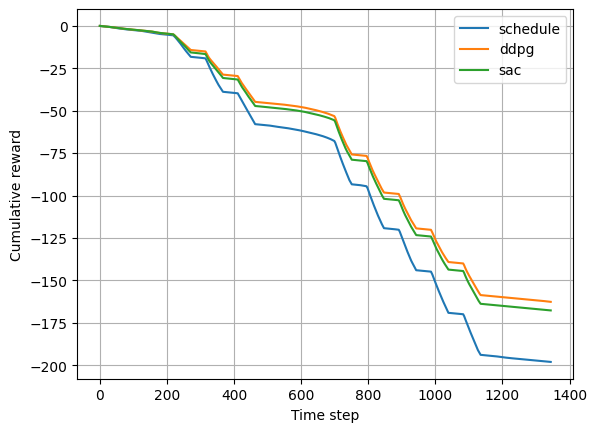

In [ ]:
import matplotlib.pyplot as plt
plt.plot(np.cumsum(data["schedule_eval-winter_2025_04_14-12:27:11"]["rewards"]), label="schedule")
plt.plot(np.cumsum(data["ddpg_train-summer_eval-winter_2025_04_14-12:25:39"]["rewards"]), label="ddpg")
plt.plot(np.cumsum(data["sac_train-summer_eval-winter_2025_04_14-10:08:56"]["rewards"]), label="sac")
plt.grid()
plt.xlabel("Time step")
plt.ylabel("Cumulative reward")
plt.legend(loc="best")

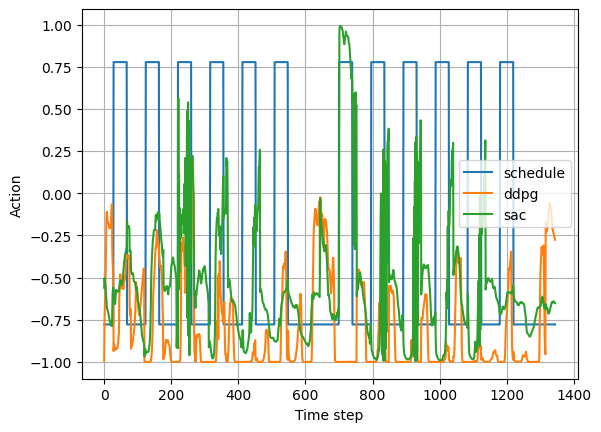

In [ ]:
import matplotlib.pyplot as plt
plt.plot(np.array(data["schedule_eval-winter_2025_04_14-12:27:11"]["actions"])[:, 1], label="schedule")
plt.plot(np.array(data["ddpg_train-summer_eval-winter_2025_04_14-12:25:39"]["actions"])[:, 1], label="ddpg")
plt.plot(np.array(data["sac_train-summer_eval-winter_2025_04_14-10:08:56"]["actions"])[:, 1], label="sac")
plt.grid()
plt.xlabel("Time step")
plt.ylabel("Action")
plt.legend(loc="best")

In [ ]:
import json

def read_json_file(file_path):
    try:
        with open(file_path, 'r') as file:
            data = json.load(file)
        return data
    except Exception as e:
        print(e)
        pass

# Example usage
file_path = "eval_results/sac_train-summer_eval-08-06_2025_04_15-01:43:44/trajectories/episode_0.json"
json_data = read_json_file(file_path)

if json_data is not None:
    print("JSON data loaded successfully:")
    print(json_data)

JSON data loaded successfully:
{'actions': [[0.05141826719045639, -0.6121522784233093], [-0.11327581852674484, -0.6630973219871521], [-0.13840782642364502, -0.6748526692390442], [-0.14648683369159698, -0.6818115711212158], [-0.15232370793819427, -0.6869191527366638], [-0.15531286597251892, -0.6893839836120605], [-0.14321601390838623, -0.6872460246086121], [-0.12731531262397766, -0.6833476424217224], [-0.11544112116098404, -0.6791760921478271], [-0.10488183051347733, -0.674959659576416], [-0.12044623494148254, -0.6776118278503418], [-0.13665105402469635, -0.6833900809288025], [-0.15867677330970764, -0.6921543478965759], [-0.17316029965877533, -0.7090639472007751], [-0.17965257167816162, -0.723373532295227], [-0.17267592251300812, -0.7356199622154236], [-0.1608540266752243, -0.7464838027954102], [-0.16377440094947815, -0.7509088516235352], [-0.18008318543434143, -0.7572010159492493], [-0.1940593421459198, -0.7642082571983337], [-0.20833778381347656, -0.7687699198722839], [-0.223356977105

In [3]:
import numpy as np
import pandas as pd

# Specify the path to your CSV file
file_path = "../configs/resources/sb1/local_weather_moffett_field_20230701_20231122.csv"

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
df.head()

,Unnamed: 0,Time,StationName,StationId,Location,TempC,DewPointC,BarometerMbar,Rain,RainTotal,WindspeedKmph,WindDirection,SkyCoverage,VisibilityKm,Humidity,TempF
0,0,20230630-1700,Mountain View Moffett Field Naval Air Station,10680520c827db24,"Mountain View, California, US",20.0,15.0,-9999.0,-9999.0,-9999.0,9.36,350,0,-9999.0,75.0,68.0
1,1,20230630-1800,Mountain View Moffett Field Naval Air Station,10680520c827db24,"Mountain View, California, US",21.0,15.0,-9999.0,-9999.0,-9999.0,12.96,350,0,-9999.0,70.0,69.8
2,2,20230630-1900,Mountain View Moffett Field Naval Air Station,10680520c827db24,"Mountain View, California, US",22.0,15.0,-9999.0,-9999.0,-9999.0,14.76,350,0,-9999.0,65.0,71.6
3,3,20230630-2000,Mountain View Moffett Field Naval Air Station,10680520c827db24,"Mountain View, California, US",25.0,15.0,-9999.0,-9999.0,-9999.0,12.96,340,0,-9999.0,50.0,77.0
4,4,20230630-2100,Mountain View Moffett Field Naval Air Station,10680520c827db24,"Mountain View, California, US",25.0,15.0,-9999.0,-9999.0,-9999.0,16.56,350,0,-9999.0,50.0,77.0


In [4]:
temperature = df["TempF"].values
times = range(len(temperature))

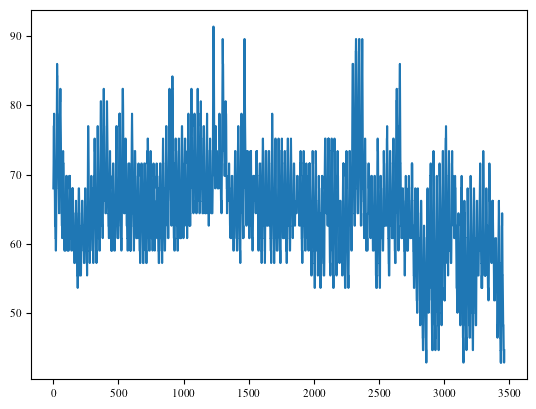

In [5]:
import matplotlib.pyplot as plt

plt.plot(times, temperature, label="Temperature")

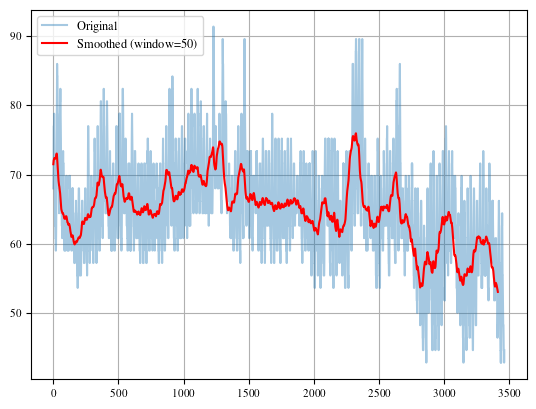

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define a simple moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Apply smoothing
window_size = 50  # Try changing this (e.g., 20, 50, 100)
smooth_temperature = moving_average(temperature, window_size)

# Adjust times too since moving average shrinks the array
smooth_times = times[:len(smooth_temperature)]

# Plot
plt.plot(times, temperature, alpha=0.4, label="Original")  # faded original
plt.plot(smooth_times, smooth_temperature, color='red', label=f"Smoothed (window={window_size})")
plt.legend()
plt.grid()
plt.show()

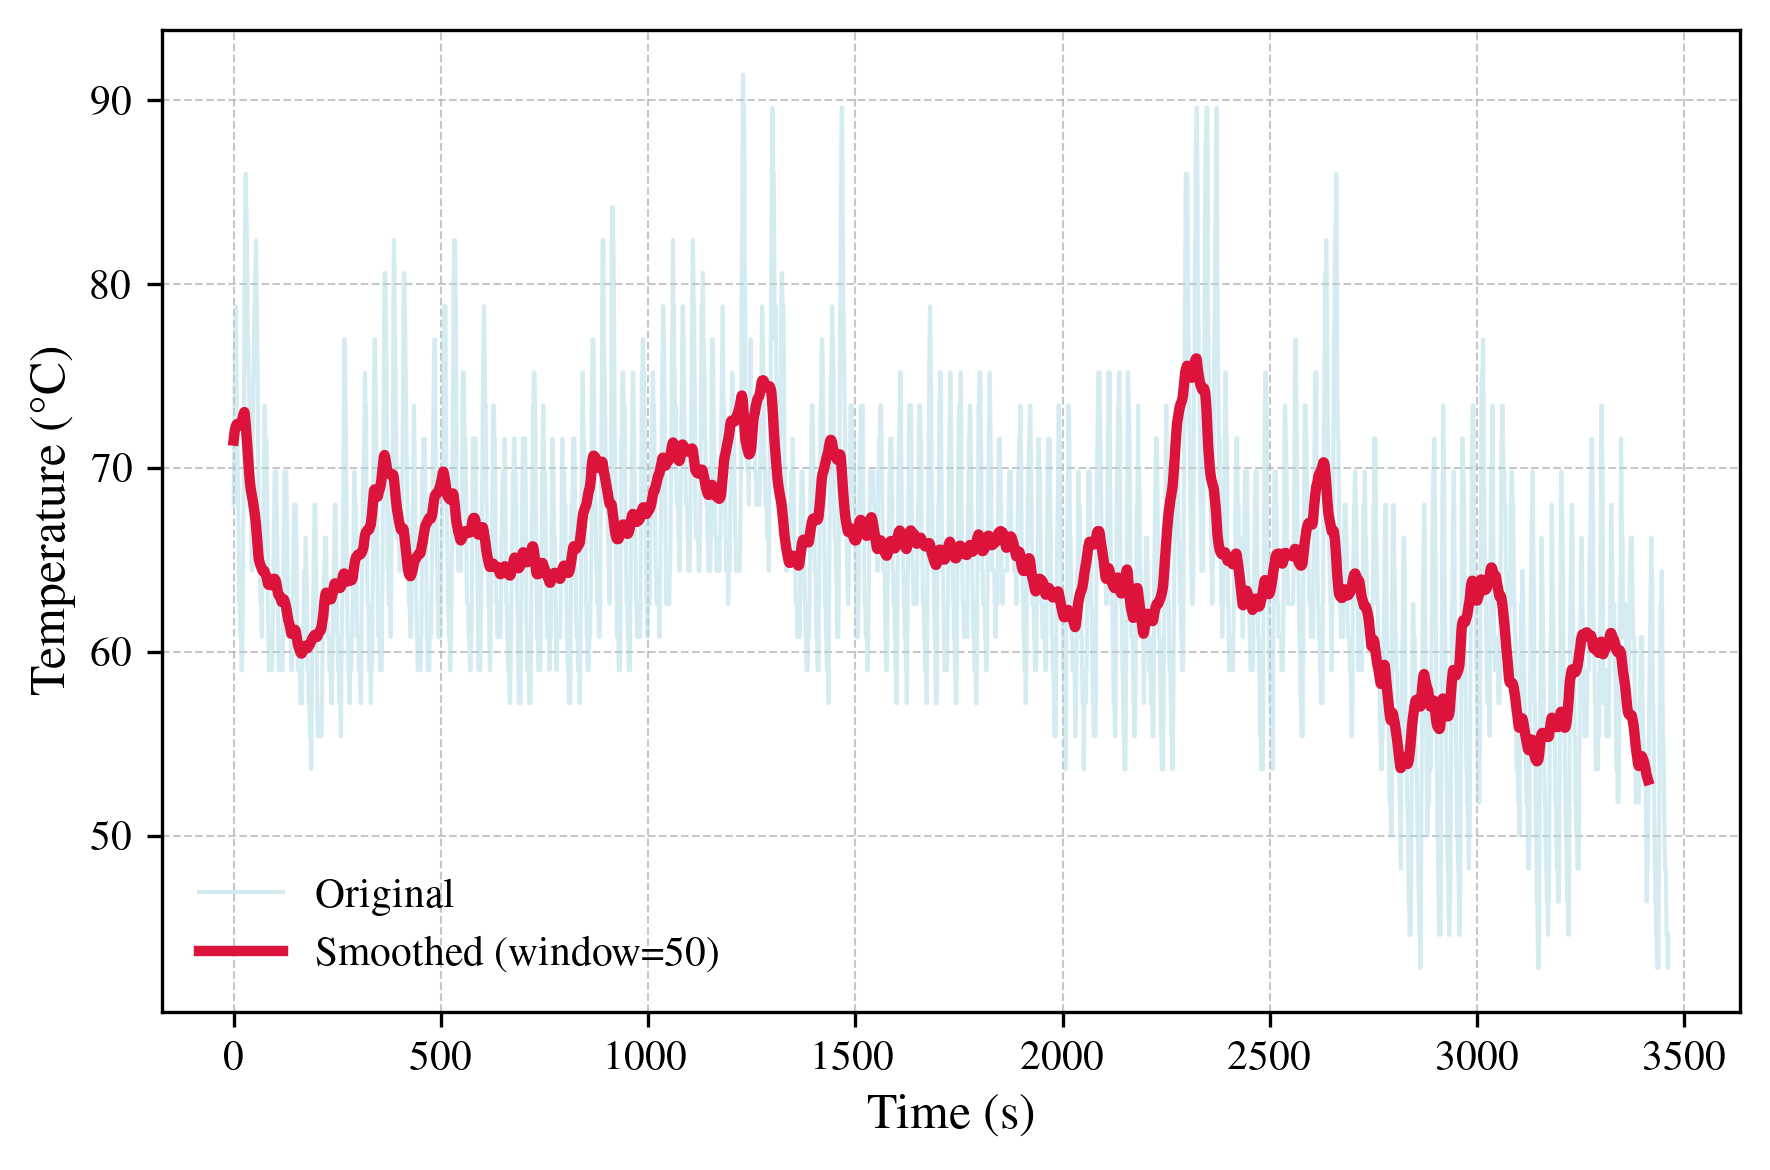

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define moving average function
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Smoothing
window_size = 50
smooth_temperature = moving_average(temperature, window_size)
smooth_times = times[:len(smooth_temperature)]

# Start polished figure
plt.figure(figsize=(6, 4), dpi=300)  # Slightly larger figure, high resolution

# Plot original
plt.plot(times, temperature, color='lightblue', linewidth=1, alpha=0.5, label="Original")

# Plot smoothed
plt.plot(smooth_times, smooth_temperature, color='crimson', linewidth=2.5, label=f"Smoothed (window={window_size})")

# Axis labels
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)

# Title (optional — comment out if you don't want a title)
# plt.title('Temperature over Time', fontsize=14)

# Grid with light style
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Ticks styling
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Legend
plt.legend(frameon=False, fontsize=10)

# Tight layout
plt.tight_layout()

# Save (for publication quality)
# plt.savefig('temperature_plot.pdf')   # PDF: vector format for papers
# plt.savefig('temperature_plot.png', dpi=600)  # High-res PNG

plt.show()

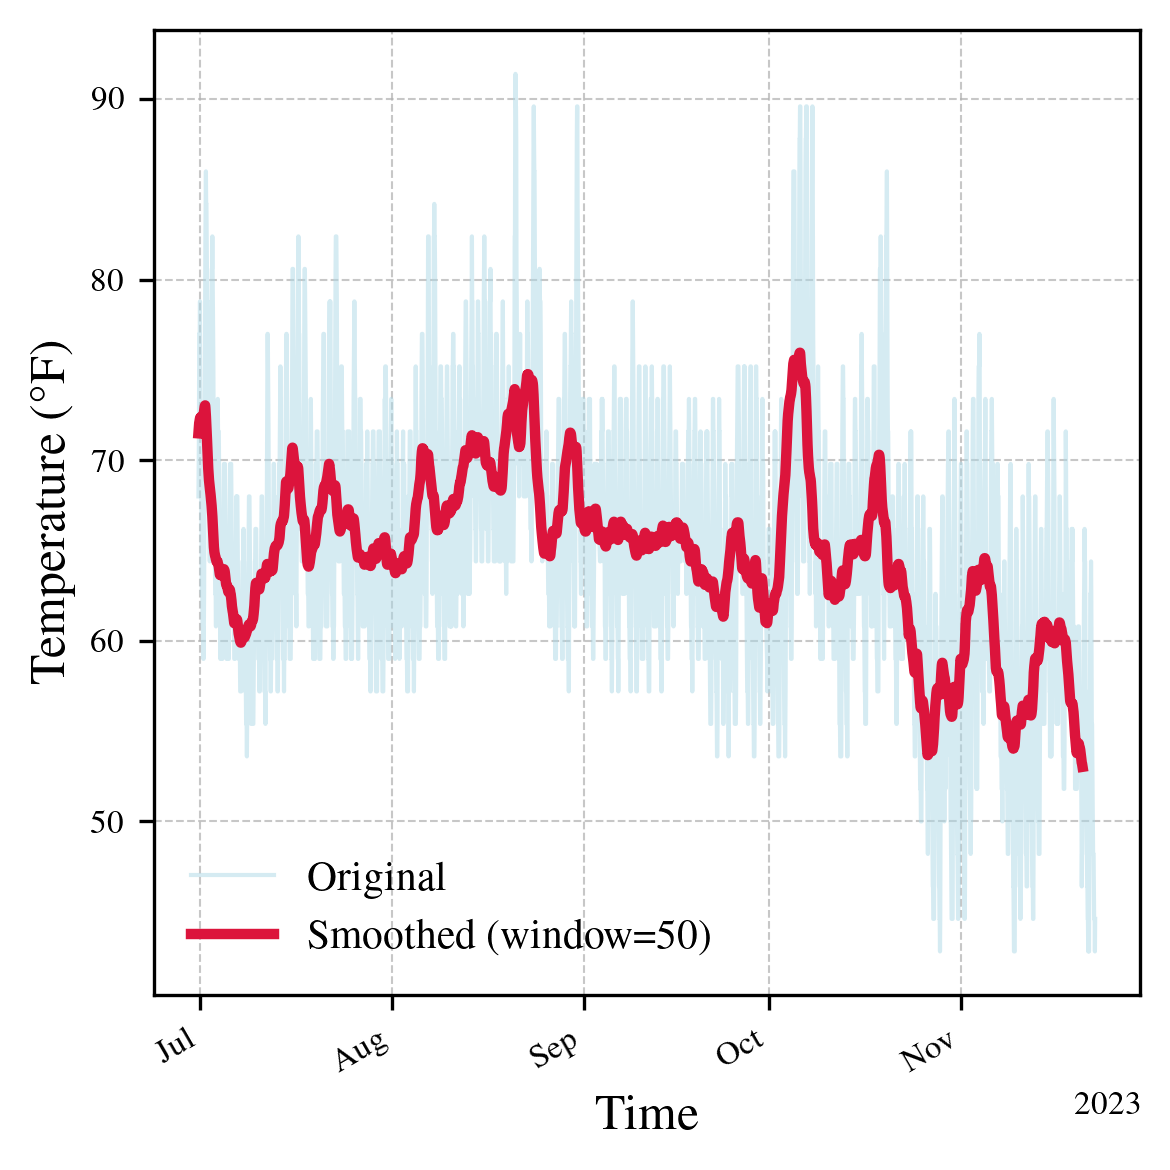

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,           # Use LaTeX to render all text
    "font.family": "serif",         # Use serif font
    "font.serif": ["Times"],        # or "Palatino", "Computer Modern Roman", etc.
    "axes.labelsize": 10,           # Font size for axis labels
    "font.size": 10,                # Base font size
    "legend.fontsize": 9,           # Legend font size
    "xtick.labelsize": 8,           # X-tick font size
    "ytick.labelsize": 8,           # Y-tick font size
})

# Suppose your times and temperature data come from your DataFrame and another source
# For example:
# df["Time"] contains: ["20230630-1700", "20230630-1800", "20230630-1900", ...]
# temperature = [...]  # corresponding temperature readings

# 1. Parse your times into datetime objects
parsed_times = [datetime.strptime(t, "%Y%m%d-%H%M") for t in df["Time"].values]

# 2. Moving average smoothing (optional)
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

window_size = 50
smooth_temperature = moving_average(temperature, window_size)
smooth_times = parsed_times[:len(smooth_temperature)]

# 3. Plotting
plt.figure(figsize=(4, 4), dpi=300)

# Plot original data
plt.plot(parsed_times, temperature, color='lightblue', linewidth=1, alpha=0.5, label="Original")

# Plot the smoothed data
plt.plot(smooth_times, smooth_temperature, color='crimson', linewidth=2.5, label=f"Smoothed (window={window_size})")

# Get the current axis
ax = plt.gca()

# Use the ConciseDateFormatter for a more compact date display
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

# Optionally rotate the tick labels a little bit, and set a smaller font size for xticks
plt.xticks(rotation=30, ha='right', fontsize=8)

# Axis labels and legend
plt.xlabel('Time', fontsize=12)
plt.ylabel('Temperature (°F)', fontsize=12)
plt.legend(frameon=False, fontsize=10)

# Grid styling
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig('plots/external_temperatures.pdf', bbox_inches='tight')

In [9]:
plt.savefig('p.pdf', bbox_inches='tight')

<Figure size 640x480 with 0 Axes>